## 2A.Filter count comparison

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report






In [ ]:
import sys
import os

print(os.getcwd()) 

c:\Users\admin\Desktop\cifar10-cnn-supervised-learning\notebooks


In [47]:
import sys
import os
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

In [49]:
from utils import train_and_evaluate
from src.utils import BaselineCNN

In [27]:
def build_model(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        layers.Conv2D(f1, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [28]:
small_model = build_model(8, 8, 16, 16)
medium_model = build_model(32, 32, 64, 64)
large_model = build_model(64, 64, 128, 128)

In [29]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

In [30]:
compile_model(small_model)
compile_model(medium_model)
compile_model(large_model)

In [52]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
# Experiment C: Standardization per-channel
mean = np.mean(x_train, axis= (0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

model_C = BaselineCNN()
model_C.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_s, acc_s, loss_s, time_s = train_and_evaluate(
    small_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

hist_m, acc_m, loss_m, time_m = train_and_evaluate(
    medium_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

hist_l, acc_l, loss_l, time_l = train_and_evaluate(
    large_model,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test
)

Test Acc: 0.5993 | Test Loss: 2.4874 | Time:271.5s
Test Acc: 0.6993 | Test Loss: 2.2889 | Time:2176.2s
Test Acc: 0.7344 | Test Loss: 2.1958 | Time:8414.6s


In [53]:
small_model.summary()
medium_model.summary()
large_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,800 (3.08 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,080,416 (27.01 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,720,278 (18.01 MB)

In [54]:
print("Model | Params | Train Acc | Val Acc | Test Acc | Time")

print("Small  |", small_model.count_params(), acc_s, hist_s.history['val_accuracy'][-1], acc_s, time_s)
print("Medium |", medium_model.count_params(), acc_m, hist_m.history['val_accuracy'][-1], acc_m, time_m)
print("Large  |", large_model.count_params(), acc_l, hist_l.history['val_accuracy'][-1], acc_l, time_l)

Model | Params | Train Acc | Val Acc | Test Acc | Time
Small  | 269266 0.5993000268936157 0.6037999987602234 0.5993000268936157 271.46637201309204
Medium | 1116970 0.6992999911308289 0.7160999774932861 0.6992999911308289 2176.2073590755463
Large  | 2360138 0.7343999743461609 0.7444000244140625 0.7343999743461609 8414.634998559952


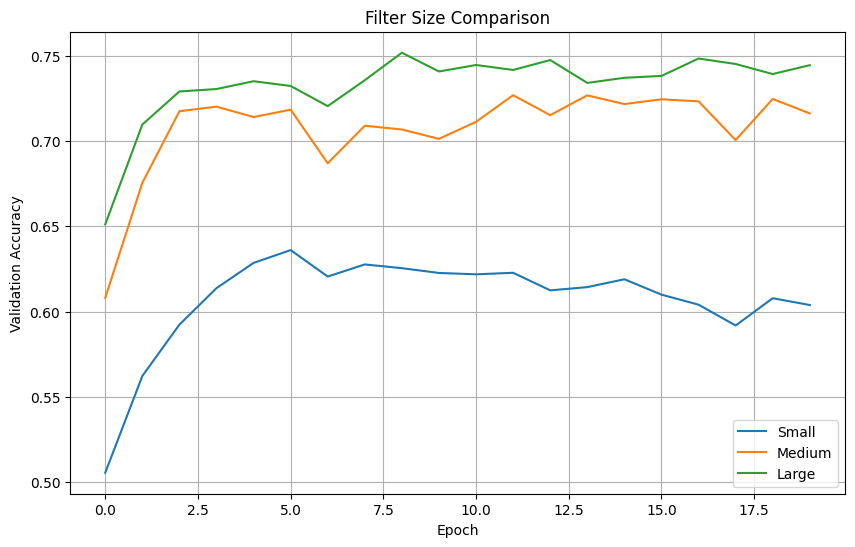

In [55]:
plt.figure(figsize=(10,6))

plt.plot(hist_s.history['val_accuracy'], label='Small')
plt.plot(hist_m.history['val_accuracy'], label='Medium')
plt.plot(hist_l.history['val_accuracy'], label='Large')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Filter Size Comparison')
plt.legend()
plt.grid()
plt.show()